Team Member 1 – Parsing Module

### File: data_extraction_M1.py
Tasks: the file is used as a Python module and must contain two functions:
extract_answers_sequence(string file_path)  
• Input: Path (as a string) to a quiz answers text file.  
• Output: List of 100 integers, where each number is 1, 2, 3, 4 (corresponding to the
answer marked by the respondent), or 0 (if the question was not answered).  
• Purpose: Parse the respondent’s answers into a structured sequence.
write_answers_sequence(list answers, int n)  


• Input: List of 100 integers (answer sequence) and an integer n (respondent ID).  
• Output: Writes the sequence to a text file named
answers_list_respondent_n.txt.  
• Purpose: Save the extracted sequence for further use

In [40]:
# MATH1604_GP_G11
# Implemented the code in a hidden compiled file for me to test it and start my own investigations
# without having to wait for other members or for the tutor to produce the required work,
# as the tutor haven't uploaded the needed code blocks or mock data yet, 
# and I have to start working as early as possible to enable flexibility and meet the deadline.
import m3_algorithms as m3

In [41]:
bigger_lists = []
for person in range(1, 41):
    bigger_lists.append(m3.extract_answers_sequence(f"../mock/M_data/mock_{person}.txt"))

### Team Member 2 – Collated answers file

collate_answer_files(string data_folder_path)  
• Input: Path to the data/ folder containing individual answer files.  
• Output: Single file collated_answers.txt in output/, with respondent
sections separated by a line containing one asterisk (*).  
• Purpose: Combine all respondent data into a unified file.

In [8]:
m3.collate_answers("../mock/M_output/collated.txt", bigger_lists)

### Team Member 3 – generating answer 100 means for each question

In [53]:
def generate_means_sequence(collated_answers_path):

    # Reads the data with each line as an element in the list
    with open(collated_answers_path, "r") as coll:
        lines = coll.readlines()

    # Initialize a list that will contain smaller lists of answer values to every question
    # for every participant as a single (smaller) list
    smaller_groups = []
    
    # Initalize a list that is updated every 100 (or less) answers of every participant
    # That is then appended into the smaller groups
    individual_list = []

    # Looping the lines list until a star is found
    for index, line in enumerate(lines):

        # Checks if star was the first element in the file then stop
        # or else continue the implementation
        if "*" in line:
            if index != 0:
                # Updates both the question group list and the participant list
                smaller_groups.append(individual_list)
                individual_list = []
            else:
                continue
        else:
            # Updates elements in the smaller participant list with every anwer until the (*)
            individual_list.append(int(line.strip()))

    # Last check if a star was not present for the last participant
    if individual_list:
        smaller_groups.append(individual_list)
        

    means = []
    for question in range(0, 100):

        question_answers = []

        # Extracting the question answer through its index from the previous loop
        for individual in smaller_groups:

            # Using that index to find eevry participant's answer to it
            answer = individual[question]
            # ignoring the no-answer questions in the calculation
            if answer != 0:
                question_answers.append(answer)

        # After looping through every answer, calculate the mean for i'th question
        # and repeat the loop for every given question.
        if len(question_answers) != 0:
            means.append(sum(question_answers)/len(question_answers))
        else:
            means.append(0)
        

    return means

print(len(generate_means_sequence("../mock/M_output/collated.txt")))
print(generate_means_sequence("../mock/M_output/collated.txt"))

100
[2.65, 2.275, 2.725, 2.4, 2.625, 2.675, 2.25, 2.25, 2.375, 2.725, 2.275, 2.35, 2.55, 2.6, 2.7, 2.425, 2.45, 2.425, 2.55, 2.275, 2.475, 2.625, 2.575, 2.35, 2.65, 2.775, 2.5, 2.45, 2.5, 2.3, 2.75, 2.375, 2.475, 2.55, 2.825, 2.4, 2.4, 3.025, 2.75, 2.5, 2.325, 2.2, 2.575, 2.3, 2.6, 2.35, 2.5, 2.5, 2.425, 2.3, 2.275, 2.65, 2.525, 2.725, 2.375, 2.55, 2.475, 2.6, 2.5, 2.325, 2.6, 2.7, 2.55, 2.7, 2.425, 2.5, 2.55, 2.2, 2.6, 2.425, 2.725, 2.425, 2.375, 2.575, 2.875, 3.05, 2.425, 2.425, 2.625, 2.45, 2.725, 2.175, 2.575, 2.85, 2.675, 2.35, 2.425, 2.65, 2.675, 2.15, 2.35, 2.225, 2.375, 2.65, 2.625, 2.375, 2.45, 3.0, 2.3, 2.4]


### Team Member 3 - Visualization (To be done later)  
visualize_data(string collated_answers _path, int n)  
  
• Input: Path to the data folder and an integer n (1 or 2).  
• Output: Visualizes the means sequence as a scatter plot (if n=1), a line plot (if
n=2) with all lines for each individual answer file displayed simultaneously on
an horizontal scale 1-100, or displays an error message (if n is neither 1 nor 2).  
• Purpose: Provide visual insights into potential patterns.  

In [54]:
import matplotlib.pyplot as plt

def visualize_data(collated_answers_path, n):
    
    means = generate_means_sequence(collated_answers_path)

    # Reads the data with each line as an element in the list
    with open(collated_answers_path, "r") as coll:
        lines = coll.readlines()

    # Initialize a list that will contain smaller lists of answer values to every question
    # for every participant as a single (smaller) list
    smaller_groups = []
    
    # Initalize a list that is updated every 100 answers of every participant
    # That is then appended into the smaller groups
    individual_list = []

    # Looping the lines list until a star is found
    for index, line in enumerate(lines):

        # Checks if star was the first element in the file then stop
        # or else continue the implementation
        if "*" in line:
            if index != 0:
                # Updates both the question group list and the participant list
                smaller_groups.append(individual_list)
                individual_list = []
            else:
                continue
        else:
            # Updates elements in the smaller participant list with every anwer until the (*)
            individual_list.append(int(line.strip()))

    # Last check if a star was not present for the last participant
    if individual_list:
        smaller_groups.append(individual_list)

    # Plots using matplotlib.pyplot according to the input (n)
    if n == 1:
        plt.scatter(range(1, 101), means)
        plt.xlabel("Question Number")
        plt.ylabel("Answers Mean")
        plt.show()
    elif n == 2:
        for answer in smaller_groups:
            plt.plot(range(1, 101), answer, alpha=0.5)
        plt.xlabel("Question Number")
        plt.ylabel("Answers Value")
        plt.show()
    else:
        raise Exception("The second given input (n) should be either 1 or 2")
        

### Output check:  

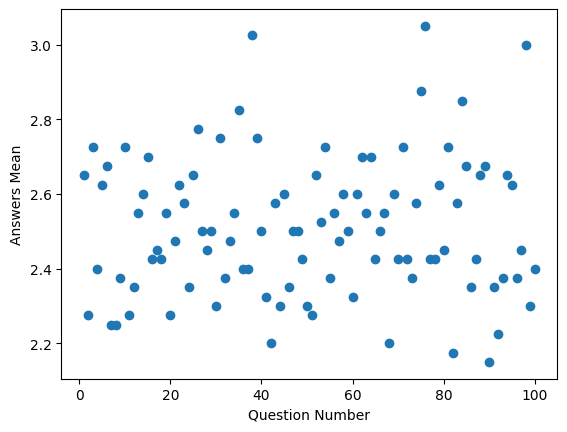

In [55]:
visualize_data("../mock/M_output/collated.txt", 1)


* The scatter plot seems reasonable given the mock data, since it is totally random and it's showing mostly means of around 2-2.6 with some outliers.

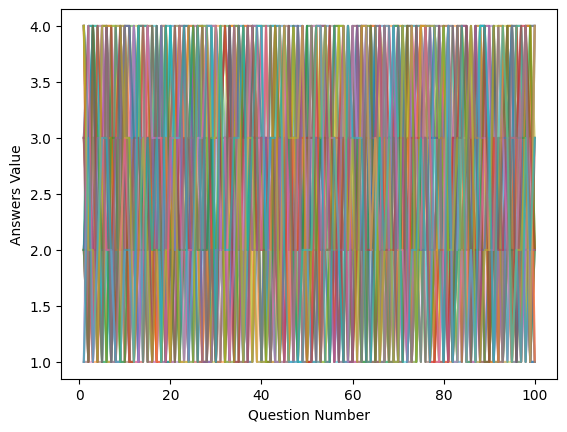

In [56]:
visualize_data("../mock/M_output/collated.txt", 2)

* The line plot seems chaotic and unclear, but this is due to the nature of the data (mock data). This technique of overlapping lines shows structure on how questions show structure, and is there a high variation across questions or are respondents mostly aligned on a specific structure. When given the real data, hopefully some structure will start showing and variations across questions will be more visible.

In [57]:
visualize_data("../mock/M_output/collated.txt", 3)

Exception: The second given input (n) should be either 1 or 2